# RTL-SDR Narrow FM (NFM) Demodulator

## Introduction

This Jupyter notebook implements a **complete Narrow FM (NFM) demodulation pipeline** using raw IQ samples captured via an RTL-SDR dongle. The goal is to receive, process, and decode a narrowband FM signal — in this case tuned to **144.470 MHz** (2m amateur band) — and produce a playable audio output.

## What is Narrow FM?

Narrow FM is a frequency modulation scheme with a small frequency deviation (typically ±2.5 kHz), commonly used in:
- Amateur radio (VHF/UHF bands)
- PMR446 / business-band radio
- Emergency services communications

It differs from wideband FM (broadcast radio) primarily in its tight channel bandwidth (~8.5 kHz IF vs. ~200 kHz for broadcast), demanding precise filtering and careful gain management to extract intelligible audio.

## Pipeline Overview

The demodulation chain implemented here consists of the following steps:

![NFM demodulation pipeline](nfm_pipeline.png)

## Key Parameters

```python
CENTER_FREQ   = 144_470_000  # Hz  — SDR tuned frequency
SIGNAL_FREQ   = 144_500_000  # Hz  — actual signal frequency
SAMPLE_RATE   =     280_000  # Hz  — IQ sample rate
AUDIO_RATE    =      48_000  # output audio sample rate (Hz)
NFM_DEVIATION =       2_500  # Hz  — peak frequency deviation
NFM_BANDWIDTH =       8_500  # Hz  — IF channel bandwidth
AUDIO_CUTOFF  =       3_400  # Hz  — audio low-pass cutoff
```

## Dependencies

Install all required packages with:

```bash
pip install numpy scipy matplotlib sounddevice jupyter ipywidgets
```

Capture IQ samples with:

```bash
rtl_sdr -f 144470000 -s 280000 -d0 -g 4 -n 1728000 capture.iq
```
The samples number 1728000 was calculated by multiplying the sample rate 280000 samples/s with the intended recording time of 6 seconds.

## Output

A 6-second decoded audio file (`output.wav`) and 11 diagnostic plots covering every stage of the pipeline — from raw IQ to the final audio waveform.

The execution of the entire Jupyter Notebook can take up to 3 min.


# Imports and Configuration


In [1]:
import numpy as np
import scipy.signal as signal
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import EngFormatter
import sounddevice as sd
import os
import warnings

warnings.filterwarnings("ignore")

# ================================================ Matplotlib style
plt.rcParams.update({
    "figure.facecolor":  "#0d1117",
    "axes.facecolor":    "#161b22",
    "axes.edgecolor":    "#30363d",
    "axes.labelcolor":   "#c9d1d9",
    "xtick.color":       "#8b949e",
    "ytick.color":       "#8b949e",
    "text.color":        "#c9d1d9",
    "grid.color":        "#21262d",
    "grid.linestyle":    "--",
    "grid.alpha":        0.6,
    "lines.linewidth":   1.2,
    "font.family":       "monospace",
    "figure.dpi":        110,
})

ACCENT  = "#58a6ff"
ACCENT2 = "#3fb950"
ACCENT3 = "#f78166"
WARN    = "#e3b341"

# ============================ SDR / Signal parameters (edit these) 
#
# 6 second recording
# - Center Frequency 144.5 MHz
# - Offset 30 kHz
# - 280 000 samples/s
# - 1.728e6 samples (6 times sample rate)
# - Gain 6 dB (close range)
#
# rtl_sdr -f 144470000 -s 280000 -d0 -g 6 -n 1728000 capture.iq
#
IQ_FILE         = "capture.iq"   # path to your raw IQ file
SAMPLE_RATE_IQ  = 280_000        # RTL-SDR sample rate (Hz)
CENTER_FREQ     = 144_470_000    # tuned centre frequency (Hz)
SIGNAL_FREQ     = 144_500_000    # actual signal frequency (Hz)

AUDIO_RATE      = 48_000         # output audio sample rate (Hz)
NFM_DEVIATION   = 2_500          # narrow FM deviation (Hz)
NFM_BANDWIDTH   = 8_500          # pre-demod IF filter bandwidth (Hz)
AUDIO_CUTOFF    = 3_400          # audio low-pass cutoff (Hz)
SQUELCH_DB      = -30            # squelch threshold (dBFS)

PLAY_AUDIO      = True           # set False to skip playback
SAVE_WAV        = True           # save demodulated audio to WAV
WAV_OUTPUT      = "output.wav"

print(f"[CONFIG]  IQ file      : {IQ_FILE}")
print(f"[CONFIG]  IQ rate      : {SAMPLE_RATE_IQ/1e3:.1f} kHz")
print(f"[CONFIG]  Centre freq  : {CENTER_FREQ/1e6:.4f} MHz")
print(f"[CONFIG]  Signal freq  : {SIGNAL_FREQ/1e6:.4f} MHz")
print(f"[CONFIG]  Audio rate   : {AUDIO_RATE/1e3:.1f} kHz")



[CONFIG]  IQ file      : capture.iq
[CONFIG]  IQ rate      : 280.0 kHz
[CONFIG]  Centre freq  : 144.4700 MHz
[CONFIG]  Signal freq  : 144.5000 MHz
[CONFIG]  Audio rate   : 48.0 kHz


# Load IQ File

In [2]:
def load_iq(path: str) -> np.ndarray:
    """
    Load IQ samples from an RTL-SDR capture file.

    Format:
    
    uint8   : raw 8-bit unsigned (I,Q interleaved, offset binary)
    """
    raw = np.fromfile(path, dtype=np.uint8)

    # convert offset-binary uint8 -> float32 in [-1, 1]
    raw = (raw.astype(np.float32) - 127.5) / 127.5

    # de-interleave I and Q (iq is of type complex64)
    iq = raw[0::2] + 1j * raw[1::2]
    return iq


# ============================================================ Load
iq_data = load_iq(IQ_FILE)
duration = len(iq_data) / SAMPLE_RATE_IQ

print(f"[LOAD]  Samples     : {len(iq_data):,}")
print(f"[LOAD]  Duration    : {duration:.3f} s")
print(f"[LOAD]  I range     : [{iq_data.real.min():.4f}, {iq_data.real.max():.4f}]")
print(f"[LOAD]  Q range     : [{iq_data.imag.min():.4f}, {iq_data.imag.max():.4f}]")


[LOAD]  Samples     : 1,728,000
[LOAD]  Duration    : 6.171 s
[LOAD]  I range     : [-0.8824, 0.8745]
[LOAD]  Q range     : [-0.8824, 0.8824]


# IQ Magnitude

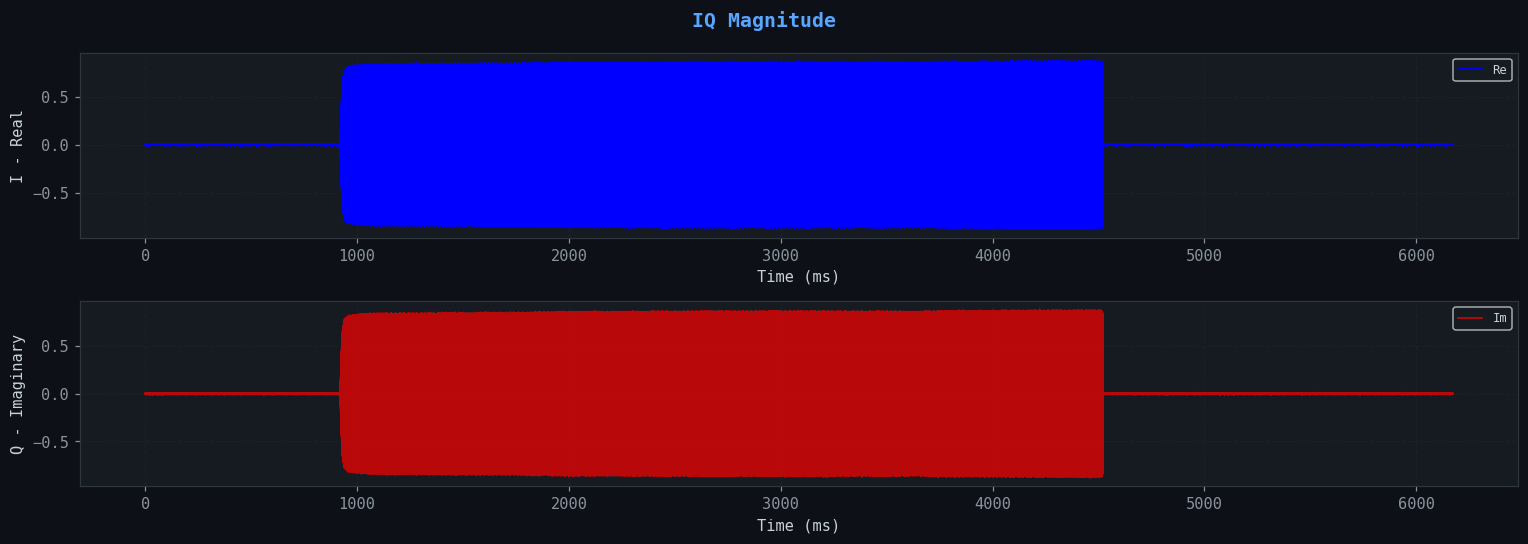

[PLOT 1]  Saved -> plot_01_iq_magnitude.png


In [3]:
iq_mag_len = len(iq_data)
iq_mag_time = np.arange(iq_mag_len) / SAMPLE_RATE_IQ * 1e3   # milliseconds
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5))
fig.suptitle("IQ Magnitude", fontsize=13,
             color=ACCENT, fontweight="bold")
ax1.plot(iq_mag_time, np.real(iq_data), color="#0000FF", label='Re')
ax1.legend(fontsize=8)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('I - Real')
ax1.grid(True)
ax2.plot(iq_mag_time, np.imag(iq_data), color="#FF0000", alpha=0.7, label='Im')
ax2.legend(fontsize=8)
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Q - Imaginary')
ax2.grid(True)
plt.tight_layout()
plt.savefig("plot_01_iq_magnitude.png", dpi=110, bbox_inches="tight")
plt.show()
print("[PLOT 1]  Saved -> plot_01_iq_magnitude.png")


# IQ - Constellation

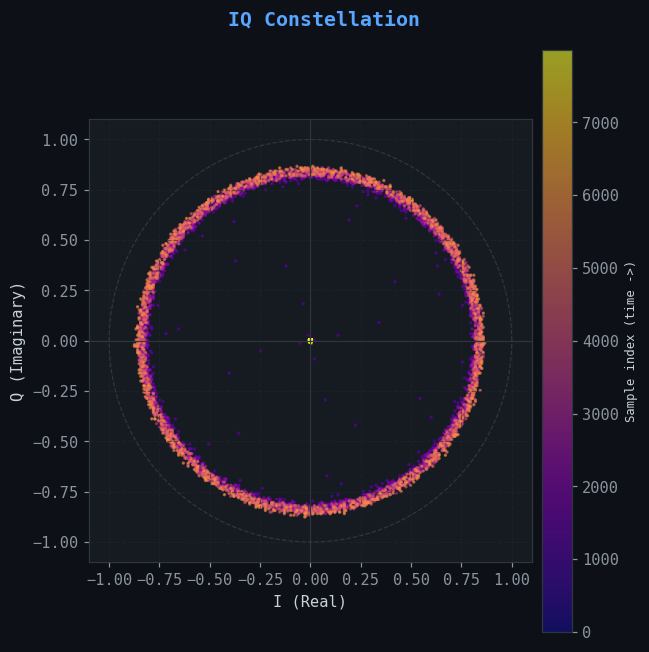

[PLOT 2]  Saved -> plot_02_constellation.png


In [4]:
max_pts = 8000
# Step through the IQ data in 8000 equidistant steps
step = max(1, len(iq_data) // max_pts)
iq_sub = iq_data[::step][:max_pts]

fig, ax = plt.subplots(figsize=(6, 6))
fig.suptitle("IQ Constellation", fontsize=13,
             color=ACCENT, fontweight="bold")

scatter = ax.scatter(iq_sub.real, iq_sub.imag,
                     c=np.arange(len(iq_sub)), cmap="plasma",
                     s=1.5, alpha=0.6)

ax.axhline(0, color="#30363d", lw=0.8)
ax.axvline(0, color="#30363d", lw=0.8)
ax.set_xlabel("I (Real)")
ax.set_ylabel("Q (Imaginary)")
ax.set_aspect("equal")
ax.grid(True)

# unit circle reference
theta = np.linspace(0, 2 * np.pi, 360)
ax.plot(np.cos(theta), np.sin(theta), color="#30363d", lw=0.8, ls="--")

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Sample index (time ->)", fontsize=8)

plt.tight_layout()
plt.savefig("plot_02_constellation.png", dpi=110, bbox_inches="tight")
plt.show()
print("[PLOT 2]  Saved -> plot_02_constellation.png")


# Power Spectral Density

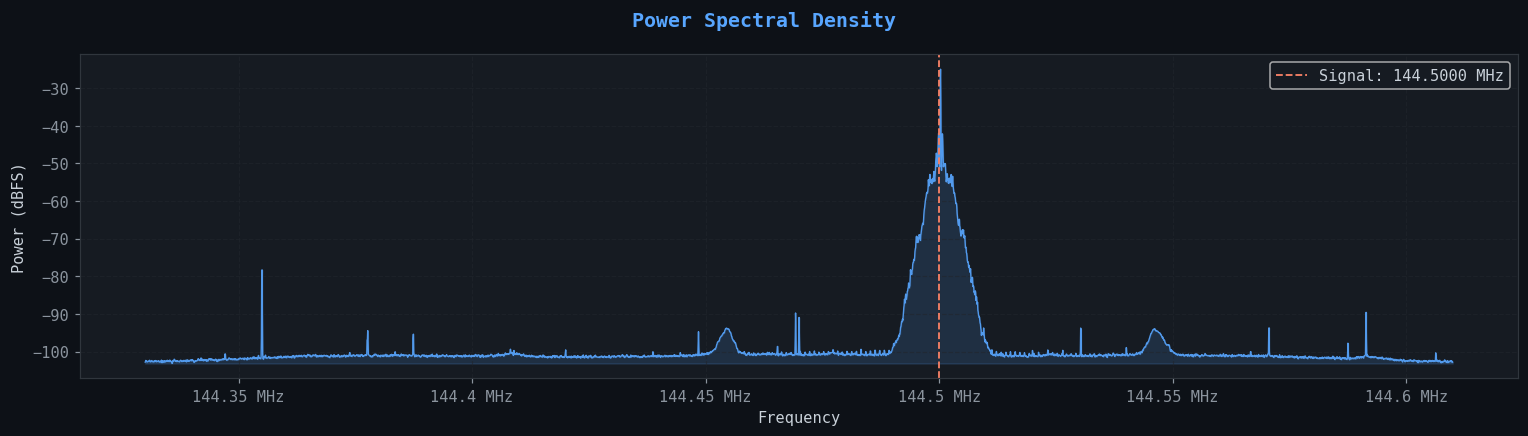

[PLOT 3]  Saved -> plot_03_psd.png


In [5]:
freq_fmt = EngFormatter(unit="Hz")
                        
# Welch PSD of raw IQ\n"
f_psd, psd = signal.welch(iq_data, fs=SAMPLE_RATE_IQ, nperseg=4096, return_onesided=False)

f_psd = np.fft.fftshift(f_psd) + CENTER_FREQ
psd   = np.fft.fftshift(psd)
psd_db = 10 * np.log10(psd + 1e-20)

fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle("Power Spectral Density", fontsize=13, color=ACCENT, fontweight="bold")

ax.plot(f_psd, psd_db, color=ACCENT, lw=0.9, alpha=0.9)
ax.fill_between(f_psd, psd_db, psd_db.min(), alpha=0.15, color=ACCENT)
ax.axvline(SIGNAL_FREQ, color=ACCENT3, lw=1.2, ls="--",
           label=f"Signal: {SIGNAL_FREQ/1e6:.4f} MHz")

ax.set_xlabel("Frequency")
ax.set_ylabel("Power (dBFS)")
ax.xaxis.set_major_formatter(freq_fmt)
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig("plot_03_psd.png", dpi=110, bbox_inches="tight")
plt.show()
print("[PLOT 3]  Saved -> plot_03_psd.png")


# Spectrogramme

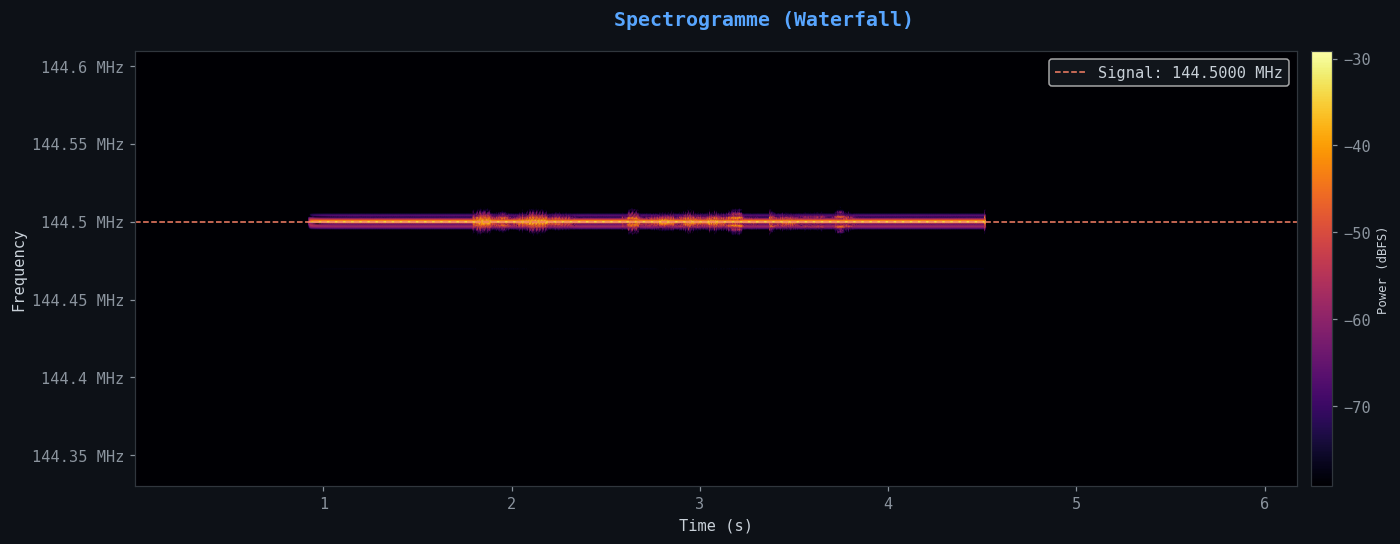

[PLOT 4]  Saved -> plot_04_waterfall.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("Spectrogramme (Waterfall)", fontsize=13,
             color=ACCENT, fontweight="bold")

f_sg, t_sg, Sxx = signal.spectrogram(
    iq_data, fs=SAMPLE_RATE_IQ,
    nperseg=512, noverlap=384,
    return_onesided=False, mode="psd"
)
f_sg  = np.fft.fftshift(f_sg) + CENTER_FREQ
Sxx   = np.fft.fftshift(Sxx, axes=0)
Sxx_db = 10 * np.log10(Sxx + 1e-20)

im = ax.pcolormesh(t_sg, f_sg, Sxx_db,
                   shading="gouraud", cmap="inferno",
                   vmin=Sxx_db.max() - 50, vmax=Sxx_db.max())

ax.axhline(SIGNAL_FREQ, color=ACCENT3, lw=1.0, ls="--",
           label=f"Signal: {SIGNAL_FREQ/1e6:.4f} MHz")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency")
ax.yaxis.set_major_formatter(freq_fmt)
ax.legend(loc="upper right")

cbar = plt.colorbar(im, ax=ax, pad=0.01)
cbar.set_label("Power (dBFS)", fontsize=8)

plt.tight_layout()
plt.savefig("plot_04_waterfall.png", dpi=110, bbox_inches="tight")
plt.show()
print("[PLOT 4]  Saved -> plot_04_waterfall.png")


# Frequency Shift to Baseband

[SHIFT]  Applied offset correction: +30,000 Hz
[SHIFT]  Frequency offset : +30,000 Hz
[SHIFT]  Signal now at    :  0 Hz (baseband)


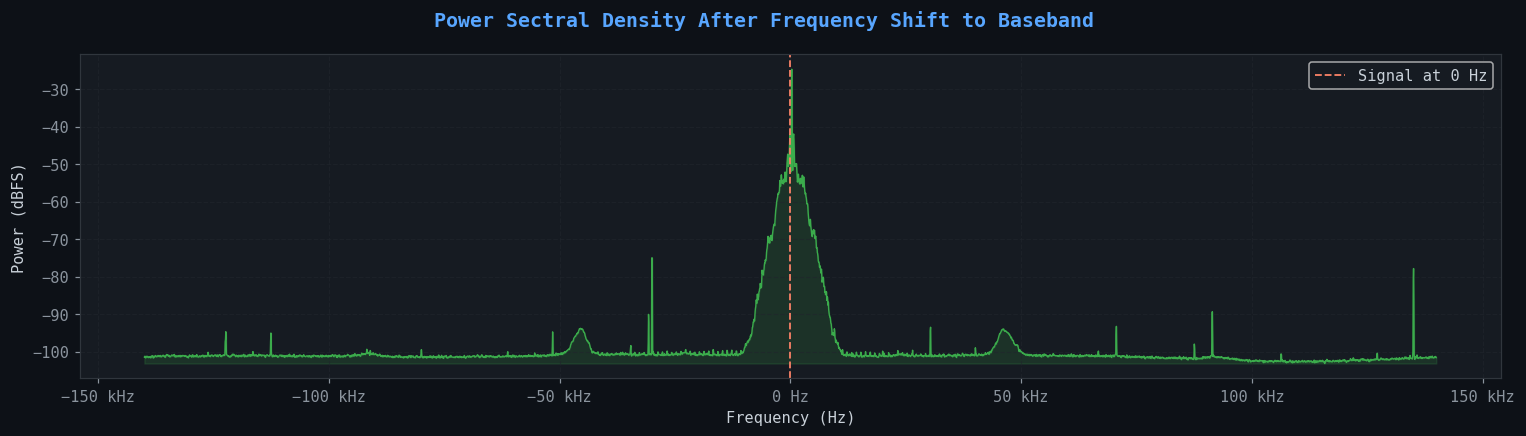

[PLOT 5]  Saved -> plot_05_shifted_psd.png


In [7]:
freq_offset = SIGNAL_FREQ - CENTER_FREQ

if abs(freq_offset) > 100:   # > 100 Hz threshold
    t_shift    = np.arange(len(iq_data)) / SAMPLE_RATE_IQ
    shift_vec  = np.exp(-1j * 2 * np.pi * freq_offset * t_shift).astype(np.complex64)
    iq_shifted = iq_data * shift_vec
    print(f"[SHIFT]  Applied offset correction: {freq_offset:+,.0f} Hz")
else:
    iq_shifted = iq_data   # already at baseband
    print("[SHIFT]  Skipped — signal already at 0 Hz")

print(f"[SHIFT]  Frequency offset : {freq_offset:+,.0f} Hz")
print(f"[SHIFT]  Signal now at    :  0 Hz (baseband)")

# ========================================= Plot 5: PSD after shift
f_bb, psd_bb = signal.welch(
    iq_shifted, fs=SAMPLE_RATE_IQ, nperseg=4096, return_onesided=False
)
f_bb   = np.fft.fftshift(f_bb)
psd_bb = np.fft.fftshift(psd_bb)

fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle("Power Sectral Density After Frequency Shift to Baseband", fontsize=13,
             color=ACCENT, fontweight="bold")

ax.plot(f_bb, 10 * np.log10(psd_bb + 1e-20), color=ACCENT2, lw=0.9, alpha=0.9)
ax.fill_between(f_bb, 10 * np.log10(psd_bb + 1e-20),
                10 * np.log10(psd_bb + 1e-20).min(),
                alpha=0.15, color=ACCENT2)
ax.axvline(0, color=ACCENT3, lw=1.2, ls="--", label="Signal at 0 Hz")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power (dBFS)")
ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig("plot_05_shifted_psd.png", dpi=110, bbox_inches="tight")
plt.show()
print("[PLOT 5]  Saved -> plot_05_shifted_psd.png")


# IF Band-Pass Filter

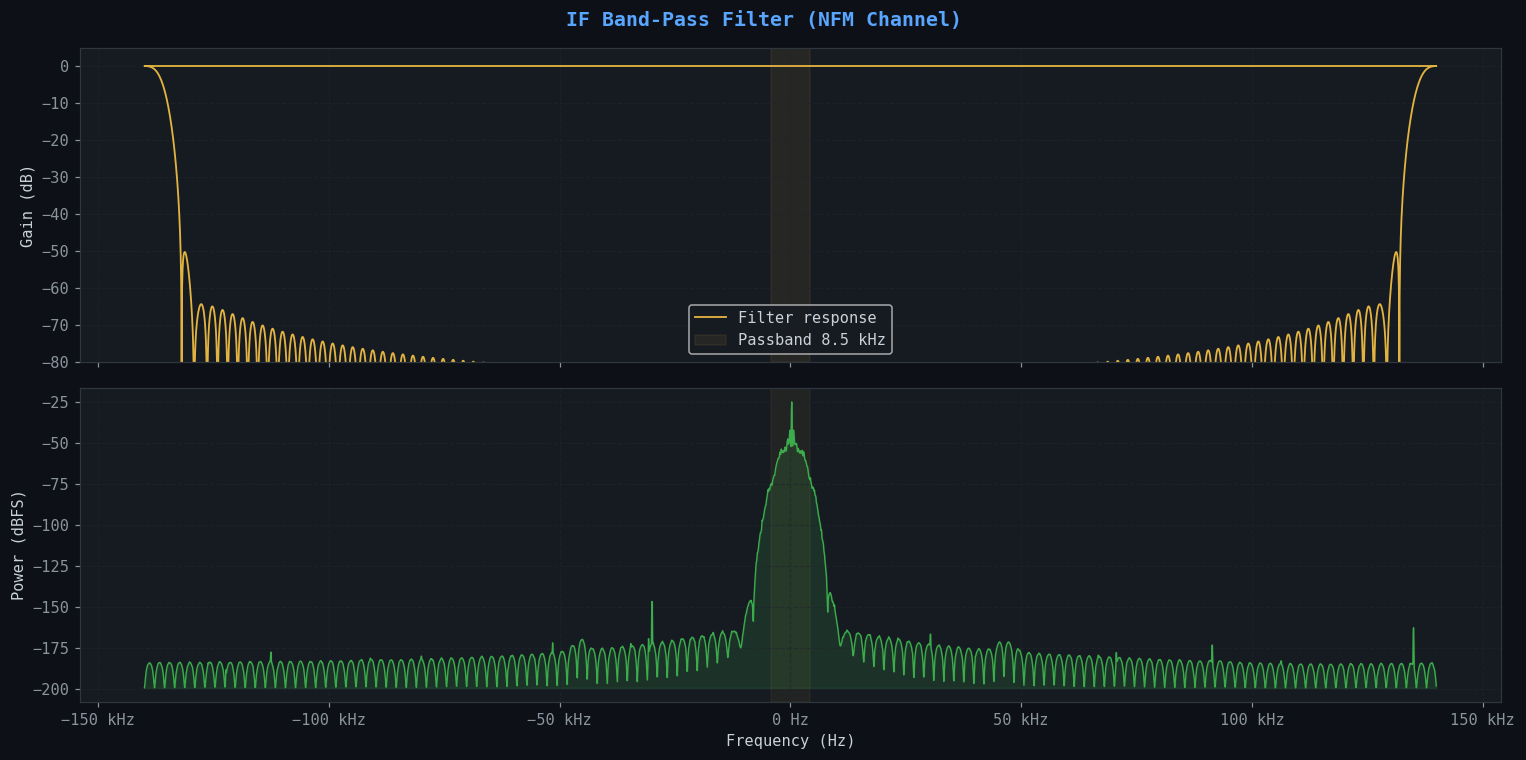

[FILTER]  IF filter taps : 128  bandwidth : 8.5 kHz
[PLOT 6]  Saved -> plot_06_if_filter.png


In [8]:
if_bw       = NFM_BANDWIDTH
taps        = 128
if_lpf_b    = signal.firwin(taps, if_bw / SAMPLE_RATE_IQ, window="hamming")

iq_filtered = signal.lfilter(if_lpf_b, 1.0, iq_shifted)

# ========================== Plot 6: Filter response + filtered PSD
f_resp, h_resp = signal.freqz(if_lpf_b, fs=SAMPLE_RATE_IQ,
                               worN=8192, whole=True)
f_resp = np.fft.fftshift(f_resp - SAMPLE_RATE_IQ / 2)
h_db   = 20 * np.log10(np.abs(np.fft.fftshift(h_resp)) + 1e-20)

f_filt, psd_filt = signal.welch(
    iq_filtered, fs=SAMPLE_RATE_IQ, nperseg=4096, return_onesided=False
)
f_filt   = np.fft.fftshift(f_filt)
psd_filt = np.fft.fftshift(psd_filt)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("IF Band-Pass Filter (NFM Channel)", fontsize=13,
             color=ACCENT, fontweight="bold")

ax1.plot(f_resp, h_db, color=WARN, lw=1.2, label="Filter response")
ax1.axvspan(-if_bw / 2, if_bw / 2, color=WARN, alpha=0.08, label=f"Passband {if_bw/1e3:.1f} kHz")
ax1.set_ylabel("Gain (dB)")
ax1.set_ylim(-80, 5)
ax1.grid(True)
ax1.legend()

ax2.plot(f_filt, 10 * np.log10(psd_filt + 1e-20), color=ACCENT2, lw=0.9, alpha=0.9)
ax2.fill_between(f_filt, 10 * np.log10(psd_filt + 1e-20),
                 10 * np.log10(psd_filt + 1e-20).min(),
                 alpha=0.15, color=ACCENT2)
ax2.axvspan(-if_bw / 2, if_bw / 2, color=WARN, alpha=0.06)
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Power (dBFS)")
ax2.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
ax2.grid(True)

plt.tight_layout()
plt.savefig("plot_06_if_filter.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"[FILTER]  IF filter taps : {taps}  bandwidth : {if_bw/1e3:.1f} kHz")
print("[PLOT 6]  Saved -> plot_06_if_filter.png")


# FM - Discrimination

## Continuous-time FM signal and demodulation
The FM signal has an instantaneous phase that encodes the modulated signal $m(\tau)$ as:
$$
s(t) = A \cos\!\left(2\pi f_c t + 2\pi k_f \int_0^t m(\tau)\,d\tau\right)
$$

The signal is recovered by differentiating the instantaneous phase:
$$
m(t) = \frac{1}{2\pi k_f} \frac{d\phi(t)}{dt}
$$
where $\phi(t)$ is the instantaneous phase and $k_f$ is the frequency deviation constant (Hz/unit).

## Discrete-time FM discriminator (as implemented)
For a complex baseband IQ sequence $x[n]$, the instantaneous phase difference between successive samples is:
$$
\phi[n] = \angle\!\left(x[n]\cdot x^{*}[n-1]\right)
$$

The normalised demodulated audio sample is then:
$$
y[n] = \frac{f_s}{2\pi\,\Delta f}\cdot\phi[n]
$$

where $f_s$ is the IQ sample rate (280 kHz) and $\Delta f$ is the peak FM deviation (2 500 Hz).
The factor $$\frac{f_s}{2\pi\,\Delta f}$$ scales the output so that a full-deviation signal maps to $\pm 1$.


[DEMOD]  Samples     : 1,728,000
[DEMOD]  Peak value  : 55.8442
[DEMOD]  RMS         : 1.2768


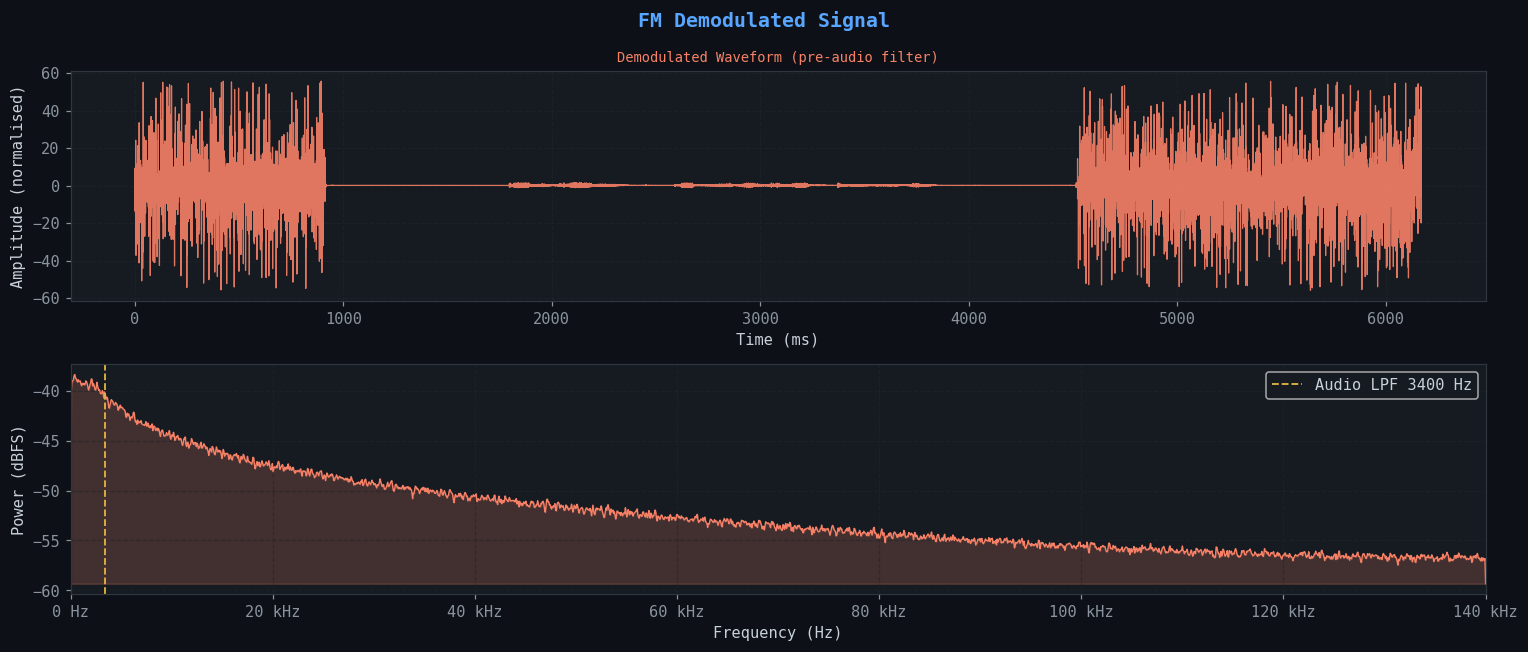

[PLOT 7]  Saved -> plot_07_demodulated.png


In [9]:
def fm_demodulate(iq: np.ndarray, sample_rate: float,
                  deviation: float) -> np.ndarray:
    """
    FM discriminator using the instantaneous phase derivative.

    phi[n] = angle(iq[n] * conj(iq[n-1]))
    audio   = phi / (2*pi * deviation/fs)
    """
    delayed   = np.concatenate(([iq[0]], iq[:-1]))
    diff      = iq * np.conj(delayed)
    phase_diff = np.angle(diff)                        # radians per sample
    gain       = sample_rate / (2 * np.pi * deviation) # normalise to [-1, 1]
    return (phase_diff * gain).astype(np.float32)


demod = fm_demodulate(iq_filtered, SAMPLE_RATE_IQ, NFM_DEVIATION)
t_demod = np.arange(len(demod)) / SAMPLE_RATE_IQ

print(f"[DEMOD]  Samples     : {len(demod):,}")
print(f"[DEMOD]  Peak value  : {np.abs(demod).max():.4f}")
print(f"[DEMOD]  RMS         : {np.sqrt(np.mean(demod**2)):.4f}")

# ==================================== Plot 7: Demodulated waveform
disp = len(demod)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))
fig.suptitle("FM Demodulated Signal", fontsize=13,
             color=ACCENT, fontweight="bold")

ax1.plot(t_demod * 1e3, demod, color=ACCENT3, lw=0.8, alpha=0.9)
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Amplitude (normalised)")
ax1.set_title("Demodulated Waveform (pre-audio filter)", color=ACCENT3, fontsize=9)
ax1.grid(True)

# PSD of demodulated signal
f_dm, psd_dm = signal.welch(demod, fs=SAMPLE_RATE_IQ,
                              nperseg=4096, return_onesided=True)
ax2.plot(f_dm, 10 * np.log10(psd_dm + 1e-20), color=ACCENT3, lw=0.9)
ax2.fill_between(f_dm, 10 * np.log10(psd_dm + 1e-20),
                 10 * np.log10(psd_dm + 1e-20).min(), alpha=0.2, color=ACCENT3)
ax2.axvline(AUDIO_CUTOFF, color=WARN, ls="--", lw=1.2,
            label=f"Audio LPF {AUDIO_CUTOFF} Hz")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Power (dBFS)")
ax2.set_xlim(0, SAMPLE_RATE_IQ / 2)
ax2.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("plot_07_demodulated.png", dpi=110, bbox_inches="tight")
plt.show()
print("[PLOT 7]  Saved -> plot_07_demodulated.png")


# Audio Low-Pass Filter

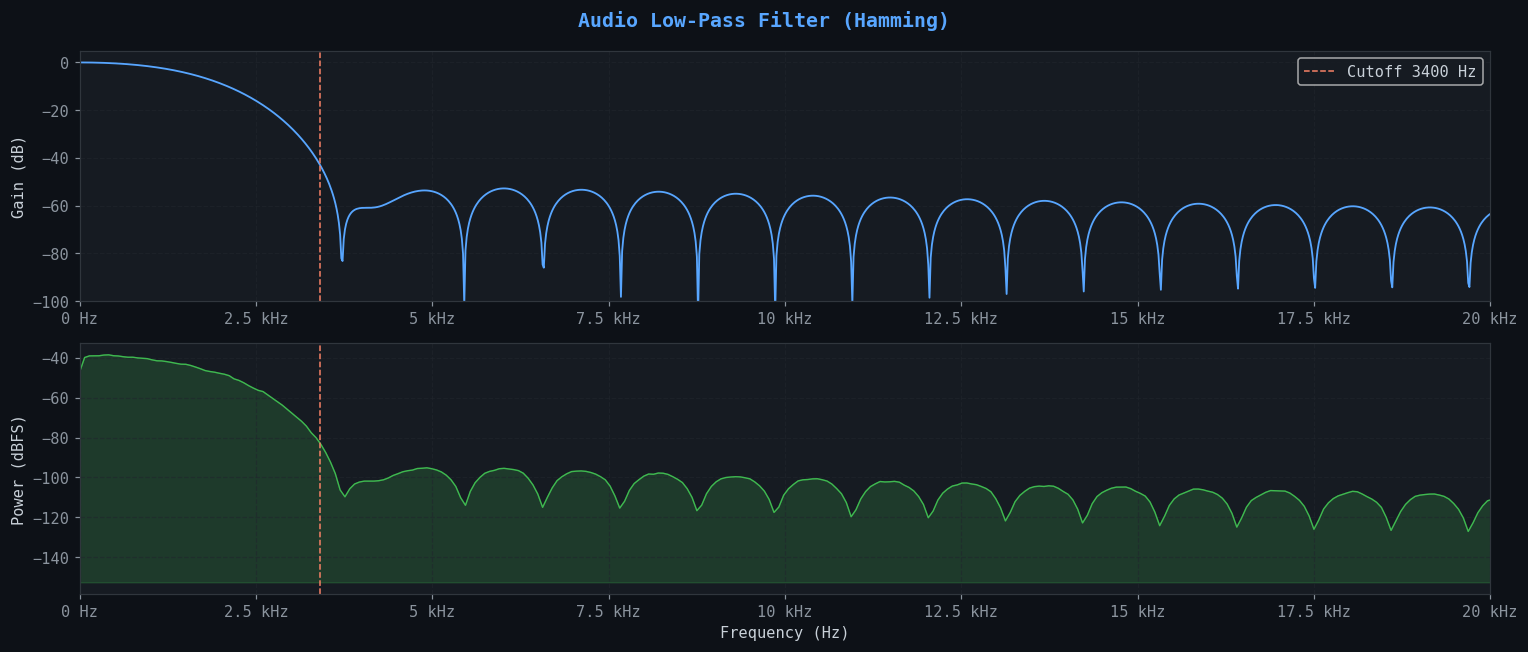

[PLOT 8]  Saved -> plot_08_audio_filter.png


In [10]:
audio_taps = 256
audio_lpf  = signal.firwin(audio_taps, AUDIO_CUTOFF / SAMPLE_RATE_IQ)
audio_if   = signal.lfilter(audio_lpf, 1.0, demod)

# =================================== Plot 8: Audio filter response
f_ar, h_ar = signal.freqz(audio_lpf, fs=SAMPLE_RATE_IQ,
                            worN=8192, whole=False)
h_ar_db = 20 * np.log10(np.abs(h_ar) + 1e-20)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))
fig.suptitle("Audio Low-Pass Filter (Hamming)", fontsize=13,
             color=ACCENT, fontweight="bold")

ax1.plot(f_ar, h_ar_db, color=ACCENT, lw=1.2)
ax1.axvline(AUDIO_CUTOFF, color=ACCENT3, ls="--", lw=1.0,
            label=f"Cutoff {AUDIO_CUTOFF} Hz")
ax1.set_ylabel("Gain (dB)")
ax1.set_ylim(-100, 5)
ax1.set_xlim(0, 20_000)
ax1.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
ax1.legend()
ax1.grid(True)

f_ai, psd_ai = signal.welch(audio_if, fs=SAMPLE_RATE_IQ,
                              nperseg=4096, return_onesided=True)
ax2.plot(f_ai, 10 * np.log10(psd_ai + 1e-20), color=ACCENT2, lw=0.9)
ax2.fill_between(f_ai, 10 * np.log10(psd_ai + 1e-20),
                 10 * np.log10(psd_ai + 1e-20).min(), alpha=0.2, color=ACCENT2)
ax2.axvline(AUDIO_CUTOFF, color=ACCENT3, ls="--", lw=1.0)
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Power (dBFS)")
ax2.set_xlim(0, 20_000)
ax2.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
ax2.grid(True)

plt.tight_layout()
plt.savefig("plot_08_audio_filter.png", dpi=110, bbox_inches="tight")
plt.show()
print("[PLOT 8]  Saved -> plot_08_audio_filter.png")


# Downsample to audio rate

[DECIM]  Factor      : 5
[DECIM]  Input rate  : 280.0 kHz
[DECIM]  Output rate : 56.0 kHz  (target 48.0 kHz)
[DECIM]  Samples     : 345,600
[DECIM]  Duration    : 6.171 s


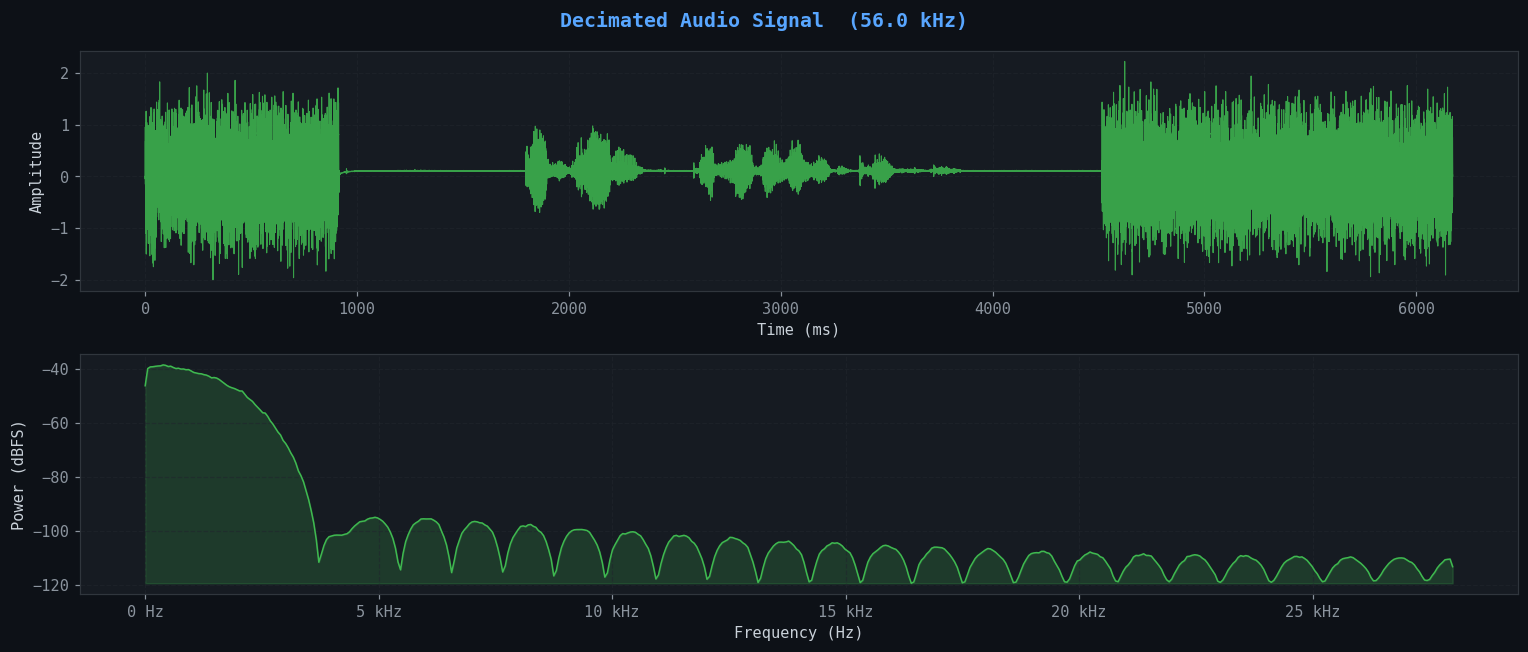

[PLOT 9]  Saved -> plot_09_audio_decimated.png


In [11]:
decim_factor = int(SAMPLE_RATE_IQ / AUDIO_RATE)
if decim_factor < 1:
    decim_factor = 1

audio_decimated = audio_if[::decim_factor].copy()
actual_rate     = SAMPLE_RATE_IQ / decim_factor

print(f"[DECIM]  Factor      : {decim_factor}")
print(f"[DECIM]  Input rate  : {SAMPLE_RATE_IQ/1e3:.1f} kHz")
print(f"[DECIM]  Output rate : {actual_rate/1e3:.1f} kHz  (target {AUDIO_RATE/1e3:.1f} kHz)")
print(f"[DECIM]  Samples     : {len(audio_decimated):,}")
print(f"[DECIM]  Duration    : {len(audio_decimated)/actual_rate:.3f} s")

# ================================ Plot 9: Decimated audio waveform
t_audio = np.arange(len(audio_decimated)) / actual_rate

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))
fig.suptitle(f"Decimated Audio Signal  ({actual_rate/1e3:.1f} kHz)", fontsize=13,
             color=ACCENT, fontweight="bold")

ax1.plot(t_audio * 1e3, audio_decimated, color=ACCENT2, lw=0.7, alpha=0.85)
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Amplitude")
ax1.grid(True)

f_aud, psd_aud = signal.welch(audio_decimated, fs=actual_rate,
                               nperseg=1024, return_onesided=True)
ax2.plot(f_aud, 10 * np.log10(psd_aud + 1e-20), color=ACCENT2, lw=1.0)
ax2.fill_between(f_aud, 10 * np.log10(psd_aud + 1e-20),
                 10 * np.log10(psd_aud + 1e-20).min(), alpha=0.2, color=ACCENT2)
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Power (dBFS)")
ax2.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
ax2.grid(True)

plt.tight_layout()
plt.savefig("plot_09_audio_decimated.png", dpi=110, bbox_inches="tight")
plt.show()
print("[PLOT 9]  Saved -> plot_09_audio_decimated.png")


# Audio Squelch & Normalisation

[SQUELCH]  Threshold : -30 dBFS
[NORM]     Peak      : 1.43536  ->  normalised to 0.9


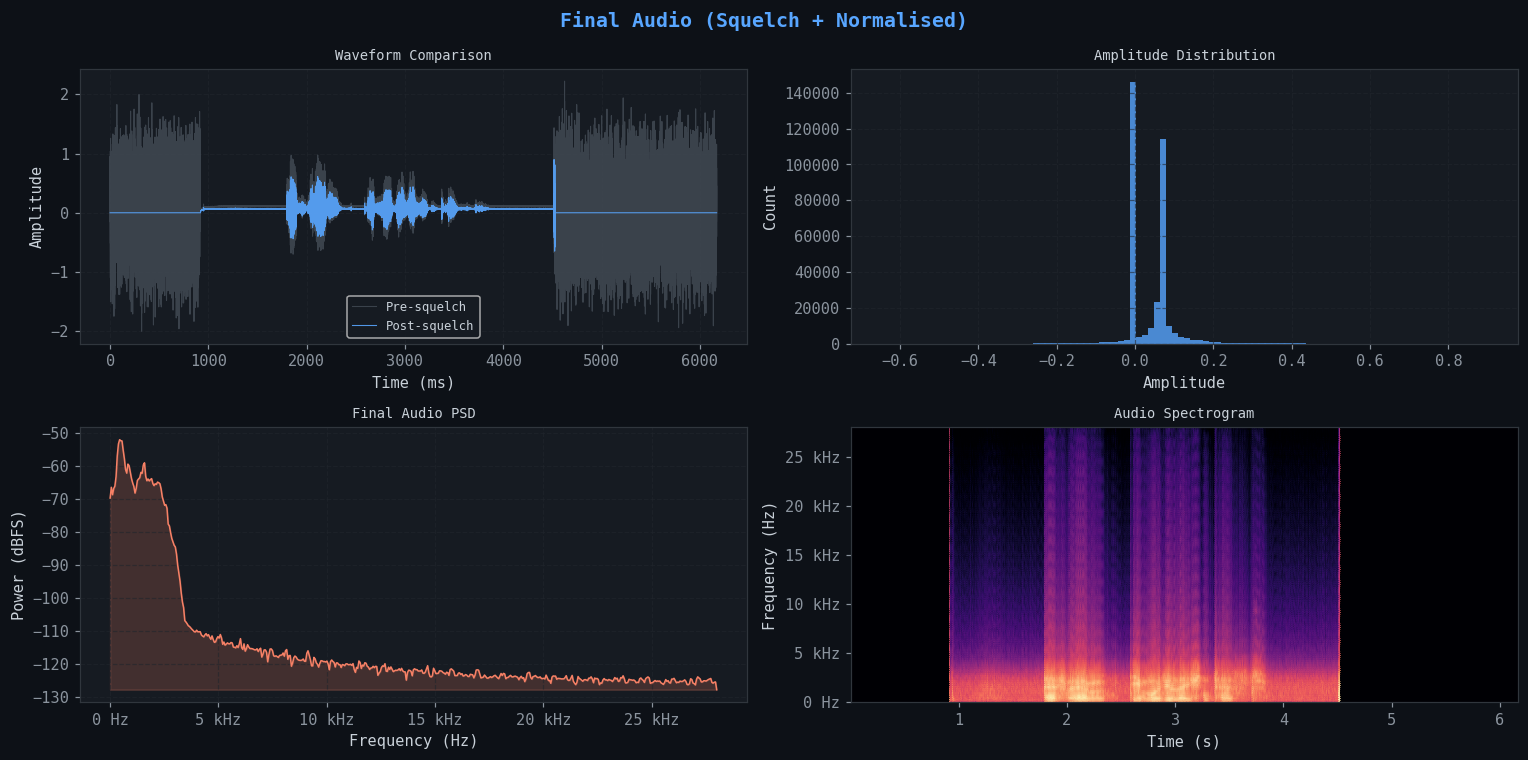

[PLOT 10]  Saved -> plot_10_final_audio.png


In [12]:
def apply_squelch(audio: np.ndarray, iq_src: np.ndarray,
                  iq_rate: float, audio_rate: float,
                  threshold_db: float, block_ms: float = 10.0) -> np.ndarray:
    """
    Simple energy squelch.  Measures IQ signal power in blocks and
    zeros audio blocks below the threshold.
    """
    iq_block   = int(iq_rate * block_ms / 1000)
    audio_block = int(audio_rate * block_ms / 1000)
    out = audio.copy()

    for i in range(0, len(audio), audio_block):
        iq_start = int(i * iq_rate / audio_rate)
        iq_end   = iq_start + iq_block
        chunk    = iq_src[iq_start:iq_end]
        if len(chunk) == 0:
            break
        power_db = 10 * np.log10(np.mean(np.abs(chunk) ** 2) + 1e-20)
        if power_db < threshold_db:
            out[i:i + audio_block] = 0.0
    return out


audio_squelched = apply_squelch(
    audio_decimated, iq_data,
    SAMPLE_RATE_IQ, actual_rate,
    SQUELCH_DB
)

# ============================================ Normalise to [-1, 1]
peak = np.abs(audio_squelched).max()
if peak > 0:
    audio_norm = (audio_squelched / peak * 0.9).astype(np.float32)
else:
    audio_norm = audio_squelched.astype(np.float32)

print(f"[SQUELCH]  Threshold : {SQUELCH_DB} dBFS")
print(f"[NORM]     Peak      : {peak:.5f}  ->  normalised to 0.9")

# ================================== Plot 10: Final audio waveform
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle("Final Audio (Squelch + Normalised)", fontsize=13,
             color=ACCENT, fontweight="bold")

# Waveform comparison
axes[0, 0].plot(t_audio * 1e3, audio_decimated, color="#444c56", lw=0.7, alpha=0.8, label="Pre-squelch")
axes[0, 0].plot(t_audio * 1e3, audio_norm,      color=ACCENT,    lw=0.7, alpha=0.9, label="Post-squelch")
axes[0, 0].set_xlabel("Time (ms)")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].set_title("Waveform Comparison", fontsize=9)
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True)

# Amplitude histogram
axes[0, 1].hist(audio_norm, bins=100, color=ACCENT, alpha=0.8, edgecolor="none")
axes[0, 1].set_xlabel("Amplitude")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Amplitude Distribution", fontsize=9)
axes[0, 1].grid(True)

# Final PSD
f_fn, psd_fn = signal.welch(audio_norm, fs=actual_rate,
                              nperseg=1024, return_onesided=True)
axes[1, 0].plot(f_fn, 10 * np.log10(psd_fn + 1e-20), color=ACCENT3, lw=1.0)
axes[1, 0].fill_between(f_fn, 10 * np.log10(psd_fn + 1e-20),
                         10 * np.log10(psd_fn + 1e-20).min(), alpha=0.2, color=ACCENT3)
axes[1, 0].set_xlabel("Frequency (Hz)")
axes[1, 0].set_ylabel("Power (dBFS)")
axes[1, 0].set_title("Final Audio PSD", fontsize=9)
axes[1, 0].xaxis.set_major_formatter(EngFormatter(unit="Hz"))
axes[1, 0].grid(True)

# Spectrogram of final audio
f_sp, t_sp, Sxx_a = signal.spectrogram(
    audio_norm, fs=actual_rate, nperseg=256, noverlap=200
)
axes[1, 1].pcolormesh(t_sp, f_sp, 10 * np.log10(Sxx_a + 1e-20),
                       shading="gouraud", cmap="magma")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("Frequency (Hz)")
axes[1, 1].set_title("Audio Spectrogram", fontsize=9)
axes[1, 1].yaxis.set_major_formatter(EngFormatter(unit="Hz"))

plt.tight_layout()
plt.savefig("plot_10_final_audio.png", dpi=110, bbox_inches="tight")
plt.show()
print("[PLOT 10]  Saved -> plot_10_final_audio.png")


# Pipeline Summary Figure

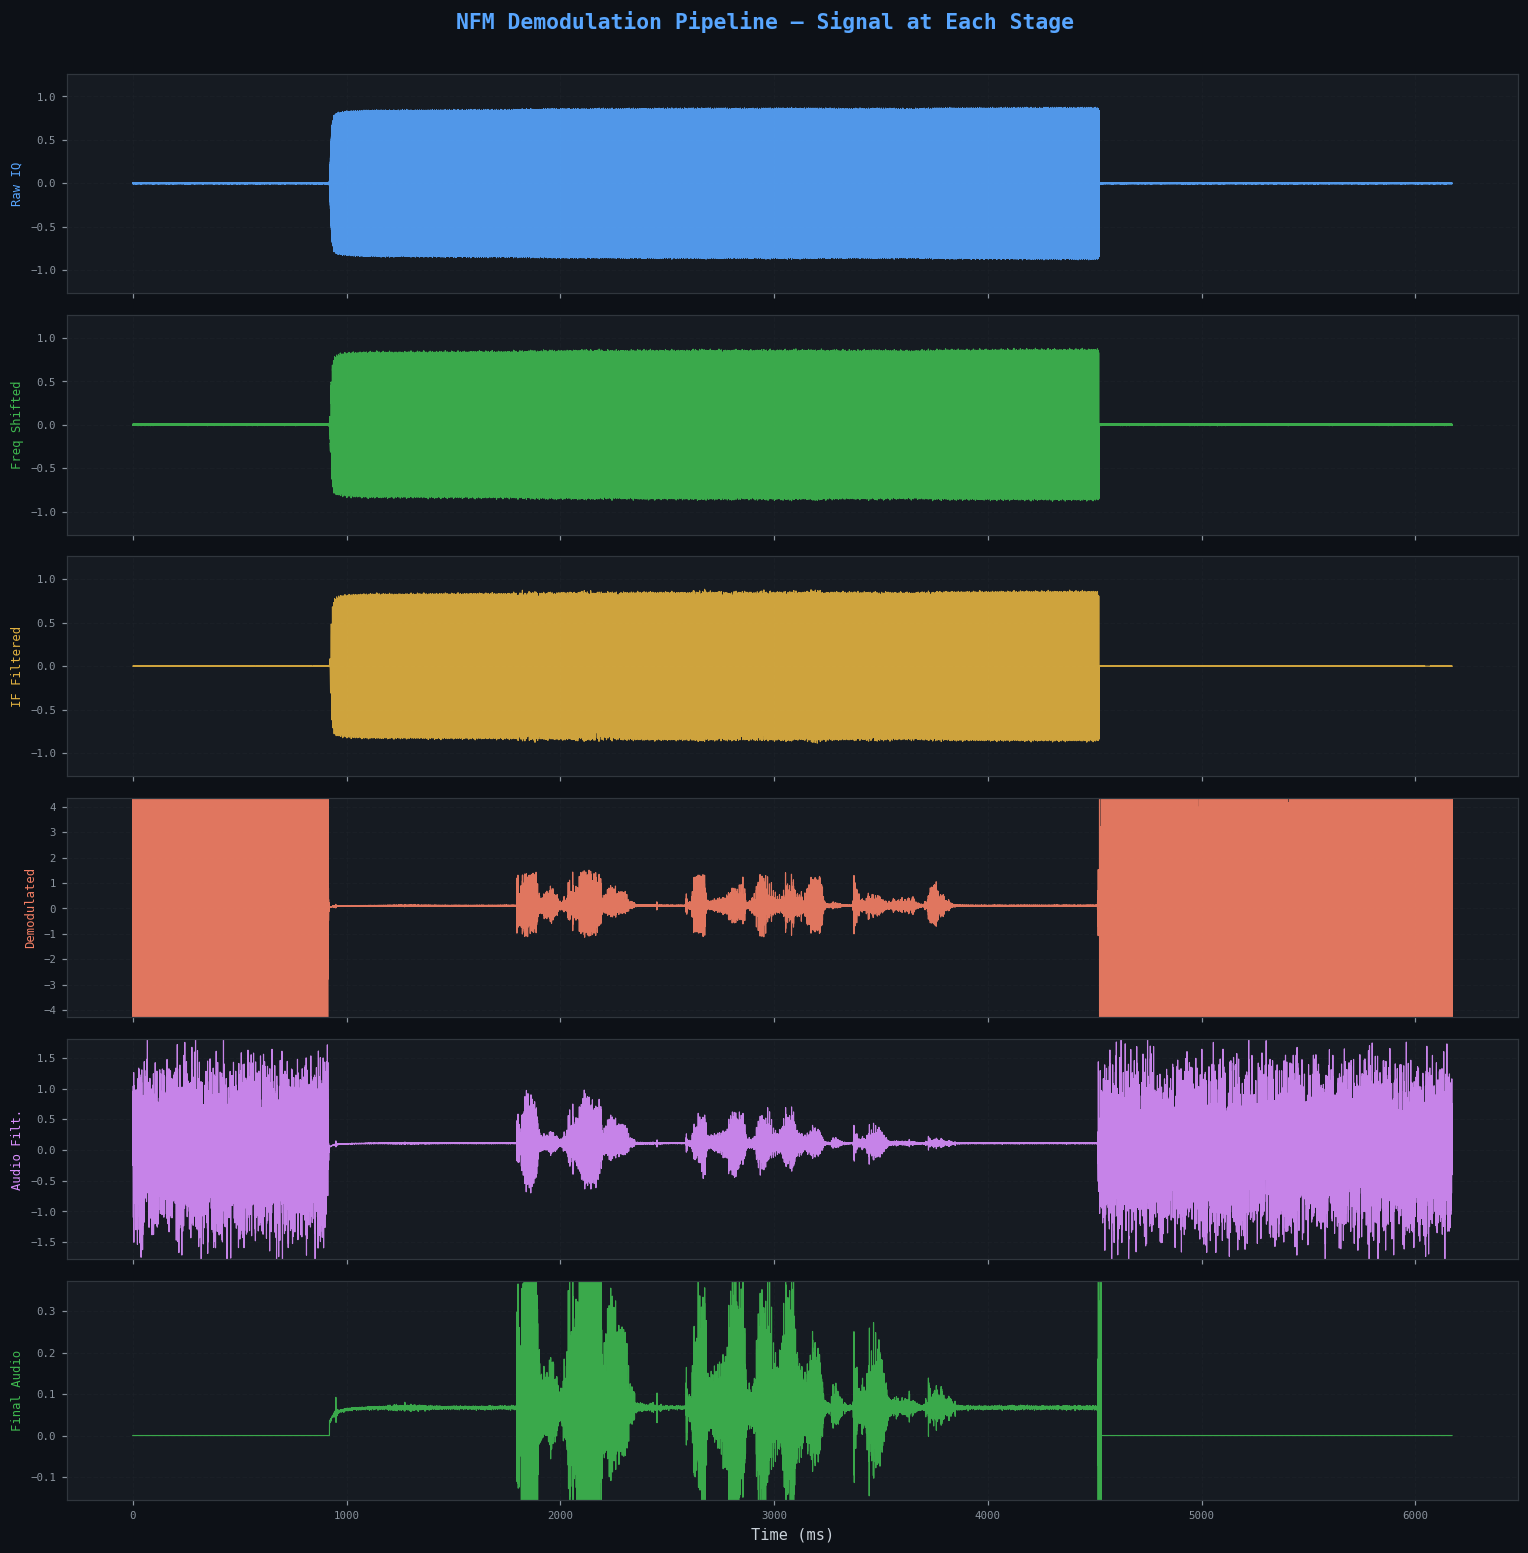

[PLOT 11]  Saved -> plot_11_pipeline.png


In [13]:
stages = [
    ("Raw IQ",        iq_data.real,       SAMPLE_RATE_IQ, ACCENT),
    ("Freq Shifted",  iq_shifted.real,    SAMPLE_RATE_IQ, ACCENT2),
    ("IF Filtered",   iq_filtered.real,   SAMPLE_RATE_IQ, WARN),
    ("Demodulated",   demod,              SAMPLE_RATE_IQ, ACCENT3),
    ("Audio Filt.",   audio_if,           SAMPLE_RATE_IQ, "#da8fff"),
    ("Final Audio",   audio_norm,         actual_rate,    ACCENT2),
]

fig, axes = plt.subplots(len(stages), 1, figsize=(14, 14))
fig.suptitle("NFM Demodulation Pipeline — Signal at Each Stage",
             fontsize=14, color=ACCENT, fontweight="bold", y=1.005)

for ax, (label, sig, fs, col) in zip(axes, stages):
    n_show = len(sig)
    t_show = np.arange(n_show) / fs * 1e3
    ax.plot(t_show, sig[:n_show], color=col, lw=0.75, alpha=0.9)
    ax.set_ylabel(label, fontsize=8, color=col)
    ax.set_ylim(np.percentile(sig, 1) * 1.5, np.percentile(sig, 99) * 1.5)
    ax.grid(True, alpha=0.4)
    ax.tick_params(labelsize=7)
    if ax != axes[-1]:
        ax.set_xticklabels([])

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.savefig("plot_11_pipeline.png", dpi=110, bbox_inches="tight")
plt.show()
print("[PLOT 11]  Saved -> plot_11_pipeline.png")


# Save WAV file and play audio

In [14]:
# ===================================================== Save to WAV
if SAVE_WAV:
    wav_data = (audio_norm * 32767).astype(np.int16)
    wav.write(WAV_OUTPUT, int(actual_rate), wav_data)
    size_kb = os.path.getsize(WAV_OUTPUT) / 1024
    print(f"[WAV]   Saved  ->  {WAV_OUTPUT}  ({size_kb:.1f} KB)")
    print(f"[WAV]   Rate   : {actual_rate:.0f} Hz")
    print(f"[WAV]   Length : {len(wav_data)/actual_rate:.3f} s")

# ======================================================== Playback
if PLAY_AUDIO:
    print(f"\n[PLAY]  Playing {len(audio_norm)/actual_rate:.2f} s of audio "
          f"@ {actual_rate:.0f} Hz ...")
    sd.play(audio_norm, samplerate=int(actual_rate), blocking=True)
    sd.wait()
    print("[PLAY]  Done.")
else:
    print("[PLAY]  Playback disabled (PLAY_AUDIO = False)")


[WAV]   Saved  ->  output.wav  (675.0 KB)
[WAV]   Rate   : 56000 Hz
[WAV]   Length : 6.171 s

[PLAY]  Playing 6.17 s of audio @ 56000 Hz ...
[PLAY]  Done.


# Summary Report

In [15]:
sep = "-" * 52

print(sep)
print("  RTL-SDR NARROW FM DEMODULATOR  —  SUMMARY")
print(sep)
print(f"  IQ file          : {IQ_FILE}")
print(f"  IQ sample rate   : {SAMPLE_RATE_IQ/1e3:.1f} kHz")
print(f"  Centre frequency : {CENTER_FREQ/1e6:.4f} MHz")
print(f"  Signal frequency : {SIGNAL_FREQ/1e6:.4f} MHz")
print(f"  Freq offset      : {freq_offset:+,.0f} Hz")
print(sep)
print(f"  IF BW (channel)  : {NFM_BANDWIDTH/1e3:.1f} kHz")
print(f"  FM deviation     : {NFM_DEVIATION/1e3:.2f} kHz")
print(f"  Audio LPF        : {AUDIO_CUTOFF} Hz")
print(f"  Decimation       : x{decim_factor}  ({SAMPLE_RATE_IQ/1e3:.0f} -> {actual_rate/1e3:.1f} kHz)")
print(f"  Squelch          : {SQUELCH_DB} dBFS")
print(sep)
print(f"  Audio duration   : {len(audio_norm)/actual_rate:.3f} s")
print(f"  Peak amplitude   : {np.abs(audio_norm).max():.4f}")
print(f"  RMS amplitude    : {np.sqrt(np.mean(audio_norm**2)):.4f}")
print(sep)
print("  Plots generated:")
plots = [
    "plot_01_raw_iq.png       — Raw IQ time domain (I, Q, magnitude)",
    "plot_02_constellation.png — IQ constellation diagram",
    "plot_03_psd.png          — Full-span PSD (Welch)",
    "plot_04_waterfall.png    — Spectrogram / waterfall",
    "plot_05_shifted_psd.png  — PSD after frequency shift",
    "plot_06_if_filter.png    — IF band-pass filter response",
    "plot_07_demodulated.png  — FM discriminator output",
    "plot_08_audio_filter.png — Audio LPF response",
    "plot_09_audio_decimated.png — Decimated audio waveform",
    "plot_10_final_audio.png  — Final audio (4-panel)",
    "plot_11_pipeline.png     — Full pipeline summary",
]
for p in plots:
    print(f"    {p}")
print(sep)


----------------------------------------------------
  RTL-SDR NARROW FM DEMODULATOR  —  SUMMARY
----------------------------------------------------
  IQ file          : capture.iq
  IQ sample rate   : 280.0 kHz
  Centre frequency : 144.4700 MHz
  Signal frequency : 144.5000 MHz
  Freq offset      : +30,000 Hz
----------------------------------------------------
  IF BW (channel)  : 8.5 kHz
  FM deviation     : 2.50 kHz
  Audio LPF        : 3400 Hz
  Decimation       : x5  (280 -> 56.0 kHz)
  Squelch          : -30 dBFS
----------------------------------------------------
  Audio duration   : 6.171 s
  Peak amplitude   : 0.9000
  RMS amplitude    : 0.0713
----------------------------------------------------
  Plots generated:
    plot_01_raw_iq.png       — Raw IQ time domain (I, Q, magnitude)
    plot_02_constellation.png — IQ constellation diagram
    plot_03_psd.png          — Full-span PSD (Welch)
    plot_04_waterfall.png    — Spectrogram / waterfall
    plot_05_shifted_psd.png  —